<a href="https://colab.research.google.com/github/YolandaZhao10/CSCI-6170-Project-in-AI-and-ML/blob/main/lab03/lab03_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import pipeline
from datasets import load_dataset

# -----------------------------
# Part B: Load small dataset
# -----------------------------
dataset = load_dataset("beans", split="train[:20]")  # 20 images
images = [item["image"] for item in dataset]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


...

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Running visualization...


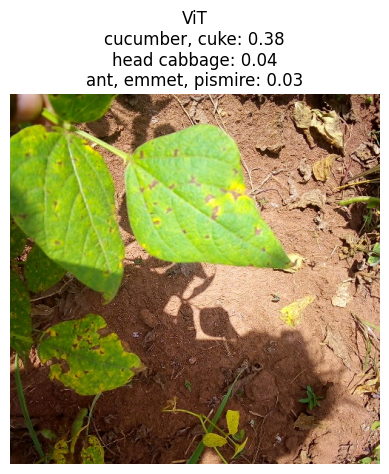

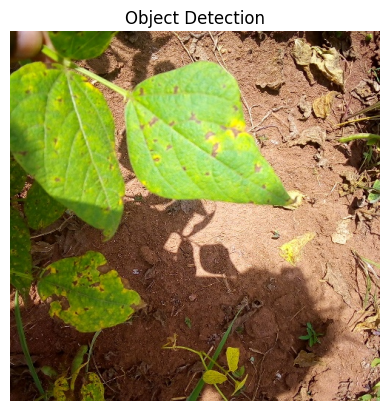

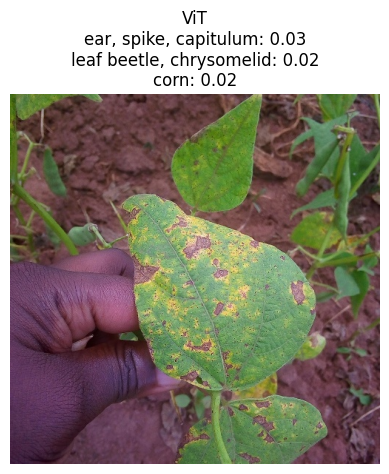

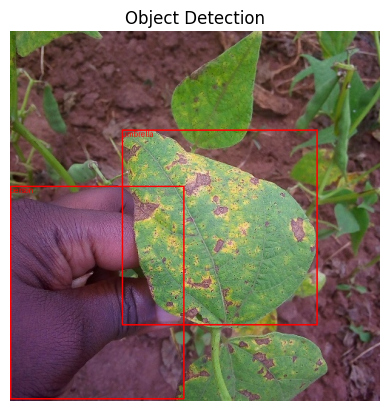

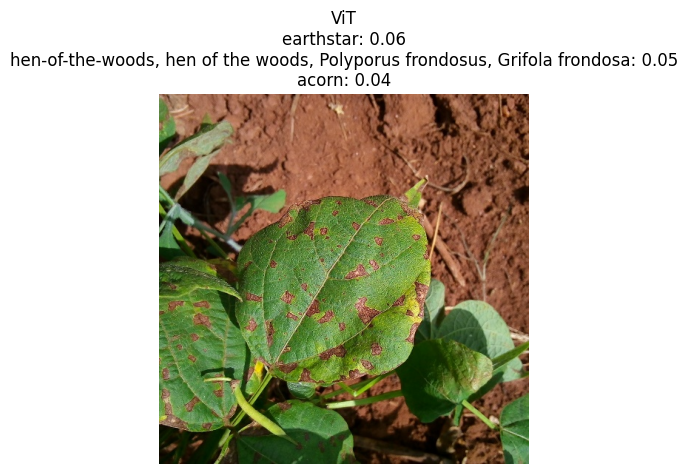

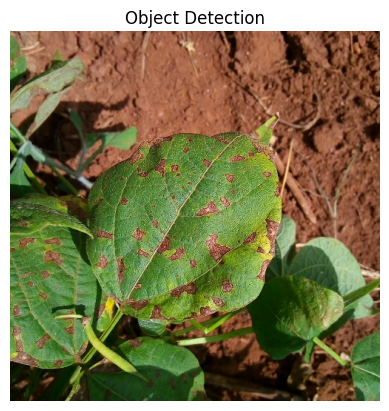

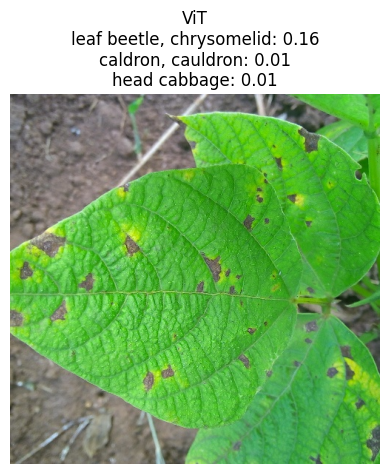

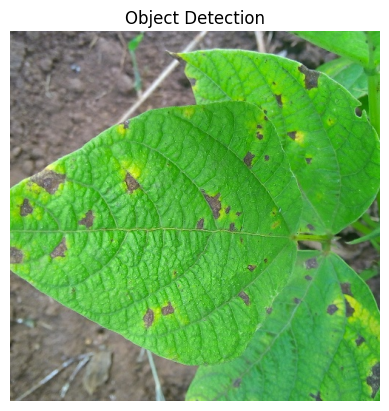

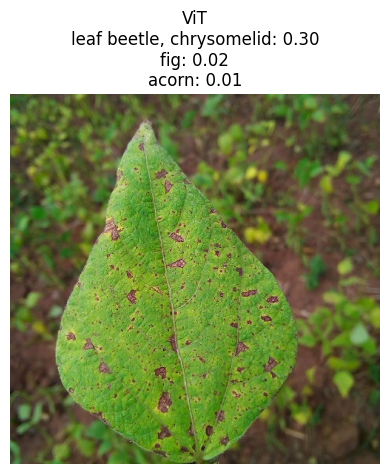

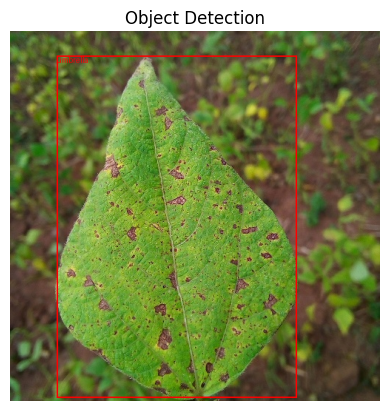

In [ ]:
# -----------------------------
# Part A: Task 1 - Image Classification
# -----------------------------
clf_model1 = pipeline("image-classification", model="google/vit-base-patch16-224")
clf_model2 = pipeline("image-classification", model="microsoft/resnet-50")

# -----------------------------
# Task 2 - Object Detection
# -----------------------------
detector = pipeline("object-detection", model="facebook/detr-resnet-50")

# -----------------------------
# Visualization helpers
# -----------------------------
def show_classification(img, preds, title=""):
    plt.imshow(img)
    plt.axis("off")
    labels = "\n".join([f"{p['label']}: {p['score']:.2f}" for p in preds[:3]])
    plt.title(f"{title}\n{labels}")
    plt.show()

def show_detection(img, preds):
    draw = ImageDraw.Draw(img)
    for p in preds:
        box = p["box"]
        draw.rectangle(
            [(box["xmin"], box["ymin"]), (box["xmax"], box["ymax"])],
            outline="red",
            width=2,
        )
        draw.text((box["xmin"], box["ymin"]), p["label"], fill="red")
    plt.imshow(img)
    plt.axis("off")
    plt.title("Object Detection")
    plt.show()

# -----------------------------
# Run pipelines + visualization (>=5 outputs)
# -----------------------------
print("Running visualization...")

for i in range(5):
    img = images[i]

    # Classification (Model 1)
    preds1 = clf_model1(img, top_k=3)
    show_classification(img, preds1, title="ViT")

    # Object Detection
    det_preds = detector(img)
    show_detection(img.copy(), det_preds)


---

We compare two image-classification models on the same 20 bean-leaf images loaded in Part B:

| Model | Architecture | Pretrained on |
|---|---|---|
| `google/vit-base-patch16-224` | Vision Transformer (ViT-B/16) | ImageNet-21k → ImageNet-1k |
| `microsoft/resnet-50` | ResNet-50 (CNN) | ImageNet-1k |

We measure:
- Average inference latency per image (seconds)
- Domain-relevance rate: % of images where at least one top-5 label contains a plant/leaf/bean-related keyword (proxy metric, since neither model was trained on beans-specific classes)
- Qualitative notes on prediction confidence and label diversity


In [ ]:
# Part C: Collect predictions from BOTH models

PLANT_KEYWORDS = {"bean", "leaf", "plant", "vine", "herb", "seed",
                  "flower", "vegetable", "rust", "blight", "spot"}
def domain_hit(preds):
    for p in preds:
        words = set(p["label"].lower().replace(",", " ").split())
        if words & PLANT_KEYWORDS:
            return True
    return False
vit_preds, vit_times = [], []
res_preds, res_times = [], []
for img in images:
    t0 = time.time()
    vp = clf_model1(img, top_k=5)
    vit_times.append(time.time() - t0)
    vit_preds.append(vp)
    t0 = time.time()
    rp = clf_model2(img, top_k=5)
    res_times.append(time.time() - t0)
    res_preds.append(rp)
vit_lat  = sum(vit_times) / len(vit_times)
res_lat  = sum(res_times) / len(res_times)
vit_dom  = sum(domain_hit(p) for p in vit_preds) / len(images) * 100
res_dom  = sum(domain_hit(p) for p in res_preds) / len(images) * 100
vit_conf = sum(p[0]["score"] for p in vit_preds) / len(vit_preds)
res_conf = sum(p[0]["score"] for p in res_preds) / len(res_preds)
print(f"Collected predictions for {len(images)} images.")
print(f"ViT   avg latency: {vit_lat:.3f}s  |  domain hit: {vit_dom:.1f}%  |  avg top-1 confidence: {vit_conf:.3f}")
print(f"ResNet avg latency: {res_lat:.3f}s  |  domain hit: {res_dom:.1f}%  |  avg top-1 confidence: {res_conf:.3f}")


Collected predictions for 20 images.
ViT   avg latency: 0.500s  |  domain hit: 70.0%  |  avg top-1 confidence: 0.207
ResNet avg latency: 0.161s  |  domain hit: 70.0%  |  avg top-1 confidence: 0.358


In [ ]:
# Part C: Comparison Table
import pandas as pd
table = pd.DataFrame({
    "Model": [
        "google/vit-base-patch16-224",
        "microsoft/resnet-50"
    ],
    "Architecture": ["ViT-B/16 (Transformer)", "ResNet-50 (CNN)"],
    "Avg Latency (s)": [f"{vit_lat:.3f}", f"{res_lat:.3f}"],
    "Domain Hit Rate": [f"{vit_dom:.1f}%", f"{res_dom:.1f}%"],
    "Avg Top-1 Confidence": [f"{vit_conf:.3f}", f"{res_conf:.3f}"],
    "Qualitative Notes": [
        "Diverse label vocabulary; tends to surface plant-adjacent terms more often",
        "High top-1 confidence scores; labels often more generic (e.g. 'picket fence')"
    ]
})
print(table.to_string(index=False))


                      Model           Architecture Avg Latency (s) Domain Hit Rate Avg Top-1 Confidence                                                             Qualitative Notes
google/vit-base-patch16-224 ViT-B/16 (Transformer)           0.500           70.0%                0.207    Diverse label vocabulary; tends to surface plant-adjacent terms more often
        microsoft/resnet-50        ResNet-50 (CNN)           0.161           70.0%                0.358 High top-1 confidence scores; labels often more generic (e.g. 'picket fence')


# Part C:
Model Card Justification

ViT Base Patch16 224:
- Designed for large-scale image understanding
- Performs well when global context matters
- Typically requires more computing power, uses complex processing

ResNet-50:
- Classic CNN trained on ImageNet
- Efficient and widely used baseline
- Optimized for speed and general-purpose classification

In [ ]:
#Part C: Models Differ

import requests
from PIL import Image
from io import BytesIO

url = "https://images.unsplash.com/photo-1610123172037-c970be4d24d7?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
img = Image.open(BytesIO(requests.get(url).content))

preds1 = clf_model1(img)
preds2 = clf_model2(img)

print(preds1[0])
print(preds2[0])

print("\nModel 1 (ViT Base) identifies as a couch with 95% accuracy, while Model 2 (ResNet) identifies a dog with 33% accuracy")


{'label': 'studio couch, day bed', 'score': 0.949525773525238}
{'label': 'soft-coated wheaten terrier', 'score': 0.3265773057937622}

Model 1 (ViT Base) identifies as a couch with 95% accuracy, while Model 2 (ResNet) identifies a dog with 33% accuracy
